Model Hyparameters Config

In [18]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

# pai
seed = 42
# model = 'llava-v1.5'
# model = 'minigpt4'
# model = "instructblip"
model = "qwen-vl"
sample = False
temperature = -1
top_p = None
num_beams = 1
max_new_tokens = 512

#hyparams
use_jsd = 1
alpha = 0.6
beta = 0.6
threshold_top_p = 0.9
threshold_top_k = 20
early_exit_layers=[i for i in range(15, 32, 1)]

In [19]:
import argparse
import json
import random
import numpy as np
import torch
import torch.nn.functional as F
import torch.backends.cudnn as cudnn
from constants import INSTRUCTION_TEMPLATE, SYSTEM_MESSAGE
from eval_data_loader import COCODataSet
from llava.utils import disable_torch_init
from model_loader import ModelLoader
from tqdm import tqdm
from PIL import Image
import matplotlib.pyplot as plt
from transformers import set_seed
from chair import CHAIR
import pickle

load model

In [20]:
set_seed(seed)
disable_torch_init()

model_loader = ModelLoader(model)
tokenizer = model_loader.tokenizer

The argument `trust_remote_code` is to be used with Auto classes. It has no effect here and is ignored.


Loading Qwen-VL


Loading checkpoint shards: 100%|██████████| 10/10 [00:52<00:00,  5.21s/it]


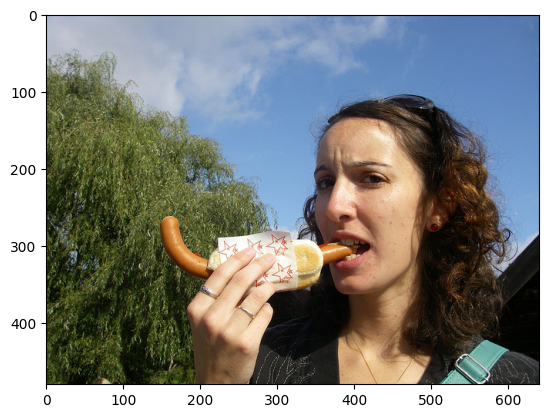

In [21]:
image_id = 520892
image_path = "/data1/zhr/datasets/coco2014/val2014/" + "COCO_val2014_"+str(image_id).zfill(12) + ".jpg"
image = Image.open(image_path).convert("RGB")
plt.imshow(image)
plt.show()


In [22]:

# save_dir = "./zfigs/"
# if not os.path.exists(save_dir):
#     os.makedirs(save_dir)
# save_path = save_dir + "COCO_val2014_"+str(image_id).zfill(12) + ".jpg"
# shutil.copy(image_path, save_path)


In [23]:
# image_id = 226988
# image_id = 433554
# image_id = 46011
image_path = "/data1/zhr/datasets/coco2014/val2014/" + "COCO_val2014_"+str(image_id).zfill(12) + ".jpg"
image = Image.open(image_path).convert("RGB")

template = INSTRUCTION_TEMPLATE[model]

query = "Please help me describe the image in detail."

# query = "Is there a snowboard in the image?" # label:yes
# query = "Is there a car in the image?" # label:no

if model == "llava-v1.5":
    model_loader.vlm_model.config.image_aspect_ratio = None

if model == "qwen-vl":
    query = "Describe this image in detail."

prefix = ''
# prefix = " The image features a group of people gathered on a boat, enjoying a day of water sports. There are several individuals on the boat, with some of them wearing life jackets and holding onto ropes. A man is riding a "

questions, kwargs = model_loader.prepare_inputs_for_model(template, query, image_path, prefix)

In [24]:
print(questions)

<|im_start|>system
You are a helpful assistant.<|im_end|>
<|im_start|>user
<img>/data1/zhr/datasets/coco2014/val2014/COCO_val2014_000000520892.jpg</img>
Please help me describe the image in detail.<|im_end|>
<|im_start|>assistant



In [25]:
# baseline
# with torch.inference_mode():
#     outputs = model_loader.llm_model.generate(
#         do_sample=sample,
#         temperature=temperature,
#         top_p=top_p,
#         num_beams=num_beams,
#         max_new_tokens=max_new_tokens,
#         # min_new_tokens=60,
#         use_cache=True,
#         **kwargs,
#     )

# output_baseline = model_loader.decode(outputs)[0]

In [26]:
use_jsd=3 # 表示用原始方法，可以得到两个概率分布
alpha = 0
early_exit_layers=[i for i in range(20, 29, 1)]
max_new_tokens=512

with torch.inference_mode():
    output_dict, uncond_output_dict = model_loader.llm_model.generate(
    # output_dict = model_loader.llm_model.generate(
        do_sample=sample,
        temperature=temperature,
        top_p=top_p,
        num_beams=num_beams,
        max_new_tokens=max_new_tokens,
        use_cache=True,
        use_jsd=use_jsd,
        alpha = alpha,
        threshold_top_p=threshold_top_p, 
        threshold_top_k=threshold_top_k,
        early_exit_layers=early_exit_layers,
        return_dict=True,
        return_dict_in_generate=True,
        output_hidden_states=True,
        output_scores=True,
        **kwargs,
    )

output_ids = output_dict.sequences
outputs = model_loader.decode(output_ids)[0]

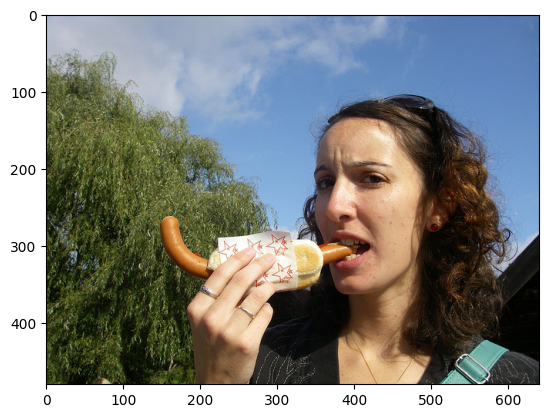

Ours:
 In the image, there is a woman standing outside with a large hot dog in her hand. The hot dog appears to be a foot long and is wrapped in paper. The woman is eating the hot dog, holding it up to her face and taking a bite. 

The scene also features a tree in the background, which adds a natural element to the setting. The woman is the main focus of the image, and the hot dog is the central object in her hand, making it the central element in the scene.


In [27]:
plt.imshow(image)
plt.show()
# print("Baseline\n", output_baseline)
# print("\n")
# print("DeCo:\n", deco_outputs)
# print("\n")
print("Ours:\n", outputs)

In [28]:
evaluator = pickle.load(open("/data1/zhr/checkpoints/chair/cache.pkl", 'rb'))
cap_dict = evaluator.compute_sample_chair(outputs, image_id)
print(cap_dict)

{'image_id': 520892, 'caption': 'In the image, there is a woman standing outside with a large hot dog in her hand. The hot dog appears to be a foot long and is wrapped in paper. The woman is eating the hot dog, holding it up to her face and taking a bite. \n\nThe scene also features a tree in the background, which adds a natural element to the setting. The woman is the main focus of the image, and the hot dog is the central object in her hand, making it the central element in the scene.', 'mscoco_hallucinated_words': [], 'mscoco_gt_words': ['person', 'hot dog', 'handbag'], 'mscoco_generated_words': ['person', 'hot dog', 'hot dog', 'person', 'hot dog', 'person', 'hot dog'], 'hallucination_idxs': [], 'metrics': {'CHAIRs': 0, 'CHAIRi': 0.0, 'Recall': 0.6666666666666666, 'Len': 99}}


In [29]:
output_ids = output_dict.sequences
if kwargs.get("input_ids", None) is not None:
    input_token_len = kwargs["input_ids"].shape[1]
else:
    input_token_len = 0

# 查找目标词的索引
target_word = "jet "
# 开始查找的id,有多个同样的词可以自己设置查找开始位置
start_idx = 0
outputs_tokens = output_ids[0, input_token_len:]
# words = tokenizer.decode(outputs_tokens[start_idx:start_idx+50]).encode("unicode_escape").decode()
for idx, token in enumerate(outputs_tokens[start_idx:]):
    word = tokenizer.decode(token)
    if word == target_word[:len(word)]:
        print(start_idx+idx, word, tokenizer.decode(outputs_tokens[start_idx+idx:start_idx+idx+10]))
        break


In [30]:
# token_idx = -68
# token_idx = -63
# token_idx = -42
# 查找到索引，赋值到token_idx
token_idx = 49 
threshold_top_k = 20
layer_logits = []
uncond_layer_logits = []

hidden_states = output_dict.hidden_states[token_idx]
uncond_hidden_states = uncond_output_dict.hidden_states[token_idx]

if model == "qwen-vl":
    layer_norm = model_loader.llm_model.transformer.ln_f
else:
    layer_norm = model_loader.llm_model.model.norm

for layer_id in range(0, 33):
    if layer_id != 32:
        layer_output = layer_norm(hidden_states[layer_id])
        uncond_layer_output = layer_norm(uncond_hidden_states[layer_id])
    else:
        layer_output = hidden_states[layer_id].clone()
        uncond_layer_output = uncond_hidden_states[layer_id].clone()
    logits = model_loader.llm_model.lm_head(layer_output)[:,-1,:]
    uncond_logits = model_loader.llm_model.lm_head(uncond_layer_output)[:,-1,:]
    layer_logits.append(logits)
    uncond_layer_logits.append(uncond_logits)

stacked_layer_logits = torch.stack(layer_logits, dim=0) # shape: (num_layers, batch_size, vocab_size)
stacked_uncond_layer_logits = torch.stack(uncond_layer_logits, dim=0)

layer_softmax = F.softmax(stacked_layer_logits, dim=-1) # shape: (num_layers, batch_size, vocab_size)
uncond_layer_softmax = F.softmax(stacked_uncond_layer_logits, dim=-1)

layer_log_softmax = F.log_softmax(stacked_layer_logits, dim=-1)
uncond_layer_log_softmax =F.log_softmax(stacked_uncond_layer_logits, dim=-1)

final_layer_softmax = layer_softmax[-1, :, :]
final_layer_log_softmax = layer_log_softmax[-1, :, :]

In [31]:
probs = layer_softmax.squeeze()
uncond_probs = uncond_layer_softmax.squeeze()
# probs = layer_log_softmax.squeeze()
# uncond_probs = uncond_layer_log_softmax.squeeze()

# 原始候选
candidate_tokens_probs, top_k_candidate_tokens_ids = torch.topk(probs[-1], dim=-1, k=threshold_top_k)
candidate_tokens_cumulative_probs = candidate_tokens_probs.cumsum(dim=-1).float()
candidate_tokens_indices = torch.searchsorted(candidate_tokens_cumulative_probs, threshold_top_p, right=False)
candidate_tokens_cutoff_idx = torch.min(candidate_tokens_indices + 1, torch.tensor(threshold_top_k))
candidate_tokens_ids = top_k_candidate_tokens_ids[:candidate_tokens_cutoff_idx]

# 纯文本候选
uncond_candidate_tokens_probs, uncond_top_k_candidate_tokens_ids = torch.topk(uncond_probs[-1], dim=-1, k=threshold_top_k)
candidate_tokens_cumulative_probs = uncond_candidate_tokens_probs.cumsum(dim=-1).float()
candidate_tokens_indices = torch.searchsorted(candidate_tokens_cumulative_probs, 0.9, right=False)
candidate_tokens_cutoff_idx = torch.min(candidate_tokens_indices + 1, torch.tensor(threshold_top_k))
uncond_candidate_tokens_ids = uncond_top_k_candidate_tokens_ids[:candidate_tokens_cutoff_idx]


top_k_words = [tokenizer.decode(t.cpu()) for t in top_k_candidate_tokens_ids]
top_p_words = [tokenizer.decode(t.cpu()) for t in candidate_tokens_ids]

uncond_top_k_words = [tokenizer.decode(t.cpu()) for t in uncond_top_k_candidate_tokens_ids]
uncond_top_p_words = [tokenizer.decode(t.cpu()) for t in uncond_candidate_tokens_ids]

final_softmax_score = F.softmax(output_dict.scores[token_idx][0], dim=-1)
final_tokens_probs, final_tokens_ids = torch.topk(final_softmax_score, dim=-1, k=threshold_top_k)

final_words = [tokenizer.decode(t.cpu()) for t in final_tokens_ids]

print("top_k_candidate_tokens\n", top_k_words)
print(candidate_tokens_probs)

print("top_p_candidate_tokens\n", top_p_words)
print(probs[-1, candidate_tokens_ids])

print("uncond_top_k_candidate_tokens\n", uncond_top_k_words)
print(uncond_candidate_tokens_probs)

print("uncond_top_p_candidate_tokens\n", uncond_top_p_words)
print(uncond_probs[-1, uncond_candidate_tokens_ids])

# print("next token logits\n", output_dict.next_token_scores[token_idx][...,candidate_tokens_ids])
# print("next token uncond logits\n", uncond_output_dict.scores[token_idx][...,candidate_tokens_ids])
# print("target layer logits\n", output_dict.target_layer_scores[token_idx][...,candidate_tokens_ids])
# print("uncond target layer logits\n", uncond_output_dict.target_layer_scores[token_idx][...,candidate_tokens_ids])
# print("target layer max probs: ", output_dict.target_max_probs[token_idx])
# print("uncond target layer max probs: ", uncond_output_dict.target_max_probs[token_idx])
# print("final logits\n", output_dict.final_scores[token_idx][...,candidate_tokens_ids])

print("final_tokens\n", final_words)
print(final_tokens_probs)

# candidate_tokens_ids = list(set(candidate_tokens_ids).union(set(uncond_candidate_tokens_ids)))
# top_p_words = [tokenizer.decode(t.cpu()) for t in candidate_tokens_ids]
# print("all_candidate_tokens\n", top_p_words)

top_k_candidate_tokens
 [' taking', ' bringing', ' placing', ' getting', ' putting', ' possibly', ' bites', ' enjoying', ' biting', ' t', ' ch', ' bite', ' bit', ' presumably', ' applying', ' preparing', ' unw', ' inserting', ' posing', ' curl']
tensor([0.7852, 0.0569, 0.0197, 0.0162, 0.0153, 0.0143, 0.0099, 0.0099, 0.0077,
        0.0041, 0.0036, 0.0034, 0.0030, 0.0027, 0.0018, 0.0018, 0.0017, 0.0013,
        0.0010, 0.0009], device='cuda:0', dtype=torch.bfloat16,
       grad_fn=<TopkBackward0>)
top_p_candidate_tokens
 [' taking', ' bringing', ' placing', ' getting', ' putting', ' possibly']
tensor([0.7852, 0.0569, 0.0197, 0.0162, 0.0153, 0.0143], device='cuda:0',
       dtype=torch.bfloat16, grad_fn=<IndexBackward0>)
uncond_top_k_candidate_tokens
 [' taking', ' bringing', ' enjoying', ' biting', ' appears', ' getting', ' bites', ' s', ' appearing', ' possibly', ' eating', ' bit', ' bring', ' ch', ' smiling', ' takes', ' t', ' seems', ' holding', ' opening']
tensor([9.1016e-01, 2.4292

In [32]:
# cross layer JSD
M = 0.5 * (layer_softmax[...,candidate_tokens_ids] + uncond_layer_softmax[...,candidate_tokens_ids])

kl1 = F.kl_div(layer_log_softmax[...,candidate_tokens_ids], M, reduction='none').mean(-1) # shape: (num_layers, batch_size)
kl2 = F.kl_div(uncond_layer_log_softmax[...,candidate_tokens_ids], M, reduction='none').mean(-1)
js_divs = 0.5 * (kl1 + kl2)
cross_layer_js_divs = js_divs.mean(-1) # shape: (num_layers,)


candidate_tokens_early_exit_probs = probs[:,candidate_tokens_ids]
uncond_candidate_tokens_early_exit_probs = uncond_probs[:,candidate_tokens_ids]



In [33]:
# print(cross_layer_js_divs[output_dict.target_layers[token_idx]])

AttributeError: 'numpy.ndarray' object has no attribute 'detach'

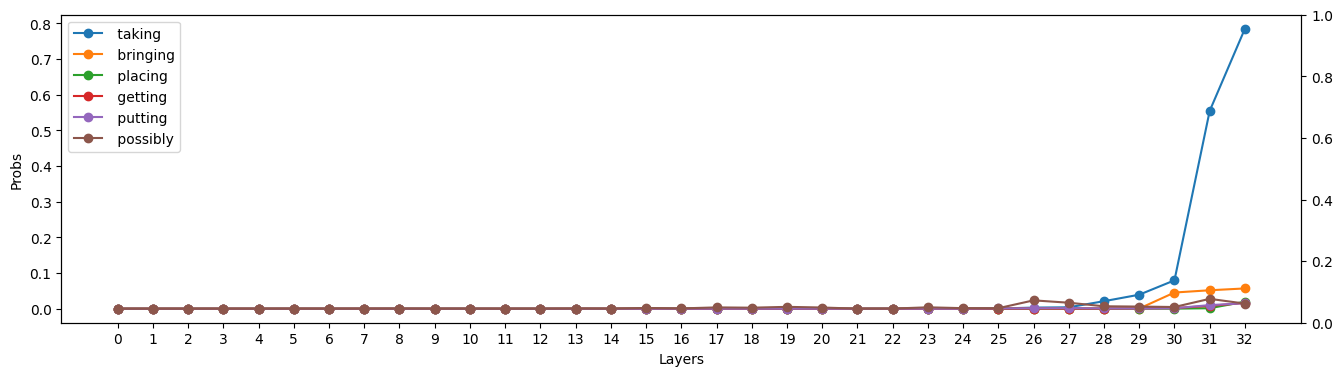

In [36]:
fig, ax = plt.subplots(figsize=(16, 4))

ax.plot(candidate_tokens_early_exit_probs.float().detach().cpu().numpy(), marker = 'o')
ax.set_xlabel("Layers")
ax.set_ylabel("Probs")
ax.set_xticks(range(33))
# ax.set_ylim(0, 1)
ax.legend(top_p_words, loc='upper left')

jsd = cross_layer_js_divs.float().detach().cpu().numpy()

ax2 = ax.twinx()
ax2.plot(jsd, marker = 'o', color = 'gray', linestyle=':')
ax2.set_ylabel("JSD")
ax2.legend(["JSD"], loc='upper right')

plt.show()